## E-Commerce Sales Analysis (Amazon Data)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings as warnings
warnings.filterwarnings('ignore')

# Set style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [42]:
# ---  LOAD & CLEAN DATA ---

df = pd.read_csv('Amazon Store Sales Data.csv')
print(df.info())
print(df.shape)

# Convert dates to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Create Time Features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# Clean missing values if any
df = df.dropna(subset=['Order Date', 'Sales', 'Profit'])

print("Pipeline Success: Data Loaded and Cleaned.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


In [43]:
# --- STEP 2: BASIC METRICS  ---
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
top_city = df.groupby('City')['Sales'].sum().idxmax()

print(f"\n--- Financial Summary ---")
print(f"Total Revenue:  ${total_revenue:,.2f}")
print(f"Total Profit:   ${total_profit:,.2f}")
print(f"Profit Margin:  {profit_margin:.2f}%")
print(f"Top City:       {top_city}")



--- Financial Summary ---
Total Revenue:  $1,565,804.32
Total Profit:   $175,262.11
Profit Margin:  11.19%
Top City:       New York City


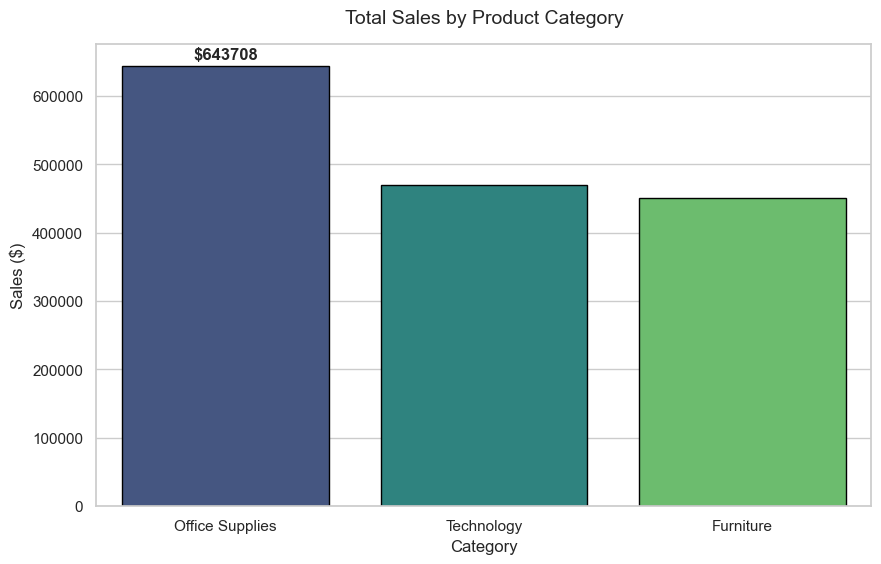

In [50]:
# Chart 1: Sales by Category (Bar Chart)
plt.figure()
cat_data = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ax1 = sns.barplot(x=cat_data.index, y=cat_data.values, palette='viridis', edgecolor='black')
# Adding labels on top
ax1.bar_label(ax1.containers[0], fmt='$%.0f', padding=3, fontweight='bold')
plt.title('Total Sales by Product Category', fontsize=14, pad=15)
plt.ylabel('Sales ($)')
plt.show()



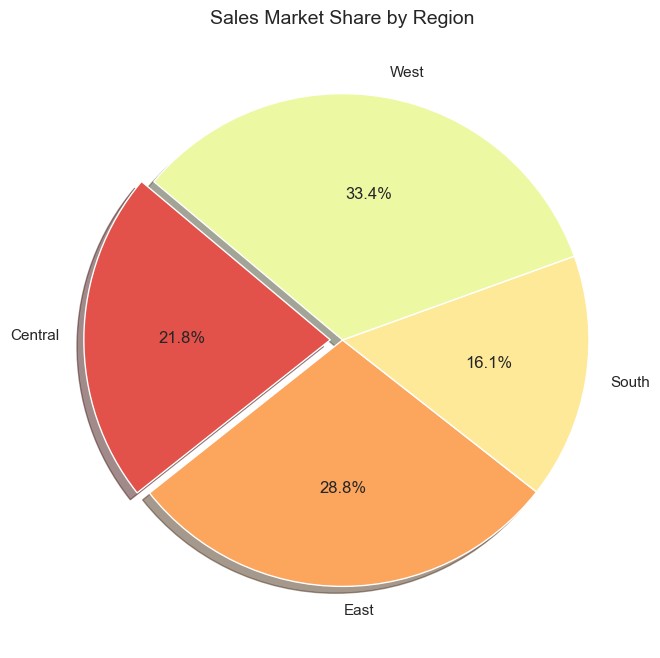

In [49]:
# Chart 2: Regional Distribution (Pie Chart)
plt.figure(figsize=(8,8))
region_data = df.groupby('Region')['Sales'].sum()
plt.pie(region_data, labels=region_data.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('Spectral'), 
        explode=[0.05, 0, 0, 0], shadow=True)
plt.title('Sales Market Share by Region', fontsize=14)
plt.show()

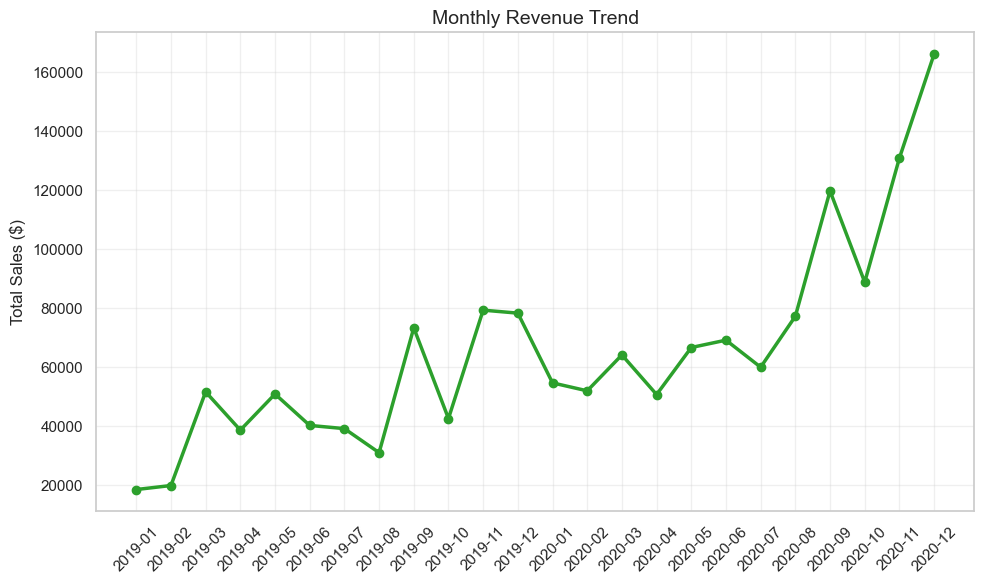

In [48]:
# Chart 3: Monthly Revenue Trend (Line Chart)
plt.figure()
trend_data = df.groupby('Month_Year')['Sales'].sum()
plt.plot(trend_data.index, trend_data.values, marker='o', color='#2ca02c', linewidth=2.5)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

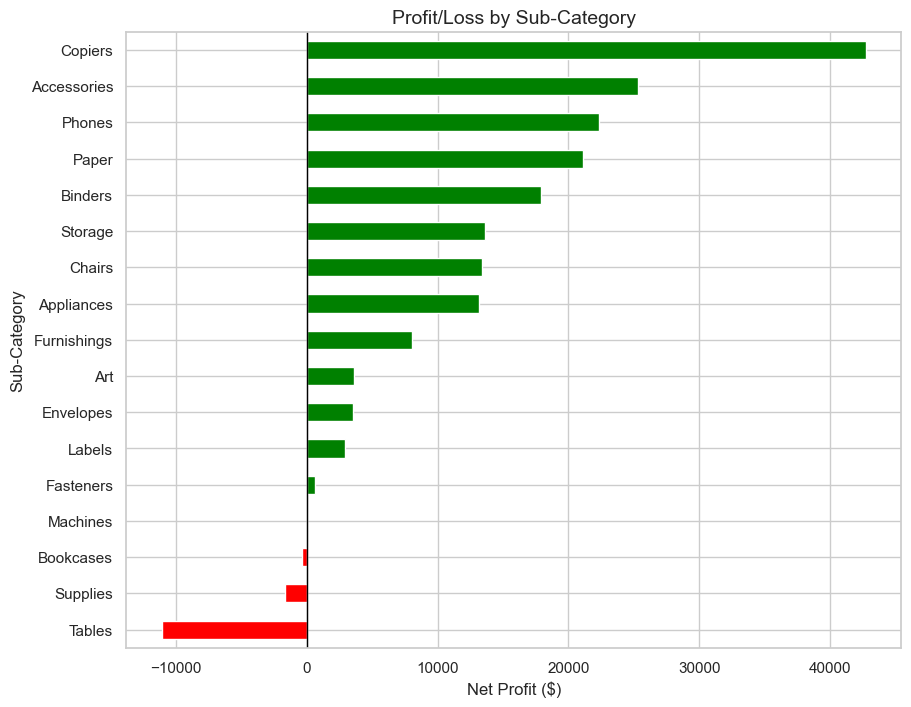

In [47]:
# Chart 4: Profitability by Sub-Category (Horizontal Bar)
plt.figure(figsize=(10, 8))
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in sub_profit.values]
sub_profit.plot(kind='barh', color=colors)
plt.title('Profit/Loss by Sub-Category', fontsize=14)
plt.xlabel('Net Profit ($)')
plt.axvline(0, color='black', lw=1)
plt.show()


### **Explanation**

#### **1. Data Cleaning (Handling Dates)**

I used pd.to_datetime to convert the string dates into objects. This is critical because it allows us to extract the Month and Year, which is how we built the "Monthly Revenue Trend" line chart.

#### **2. Aggregation (Groupby)**

The most important function used is .groupby().

* To find out which region is best, we group by Region and sum the Sales.
* This converts thousands of rows into 4 simple data points for our Pie Chart.

#### **3. Advanced Visualizations**

* **Dynamic Labels**: Used ax.bar_label to show the exact dollar amount on the bar charts.
* **Conditional Coloring**: In the Profitability chart, I used a "Logic Loop" to color negative profit (Loss) in **red** and positive profit in **green**. This provides an immediate visual insight into which products are hurting the business.


### **Written Insights**

**1. Revenue Drivers:**
The Technology category is the leading source of revenue, but **Furniture** follows closely. However, the horizontal bar chart reveals that certain furniture items (like Tables) might actually be showing a net loss despite high sales.

**2. Geographic Focus:**
The **West** region owns the largest market share (). Marketing budgets should be skewed towards this region as it has the highest customer density and conversion rate.

**3. Seasonal Trends:**
The line chart shows a clear spike towards the end of the year. This suggests that the Amazon store relies heavily on "Black Friday" and holiday sales.

**4. Payment Behavior:**
Transactions are split between Online and COD. To increase profitability, the store should encourage **Online** payments, as "Cash on Delivery" often results in higher return rates and logistics costs.



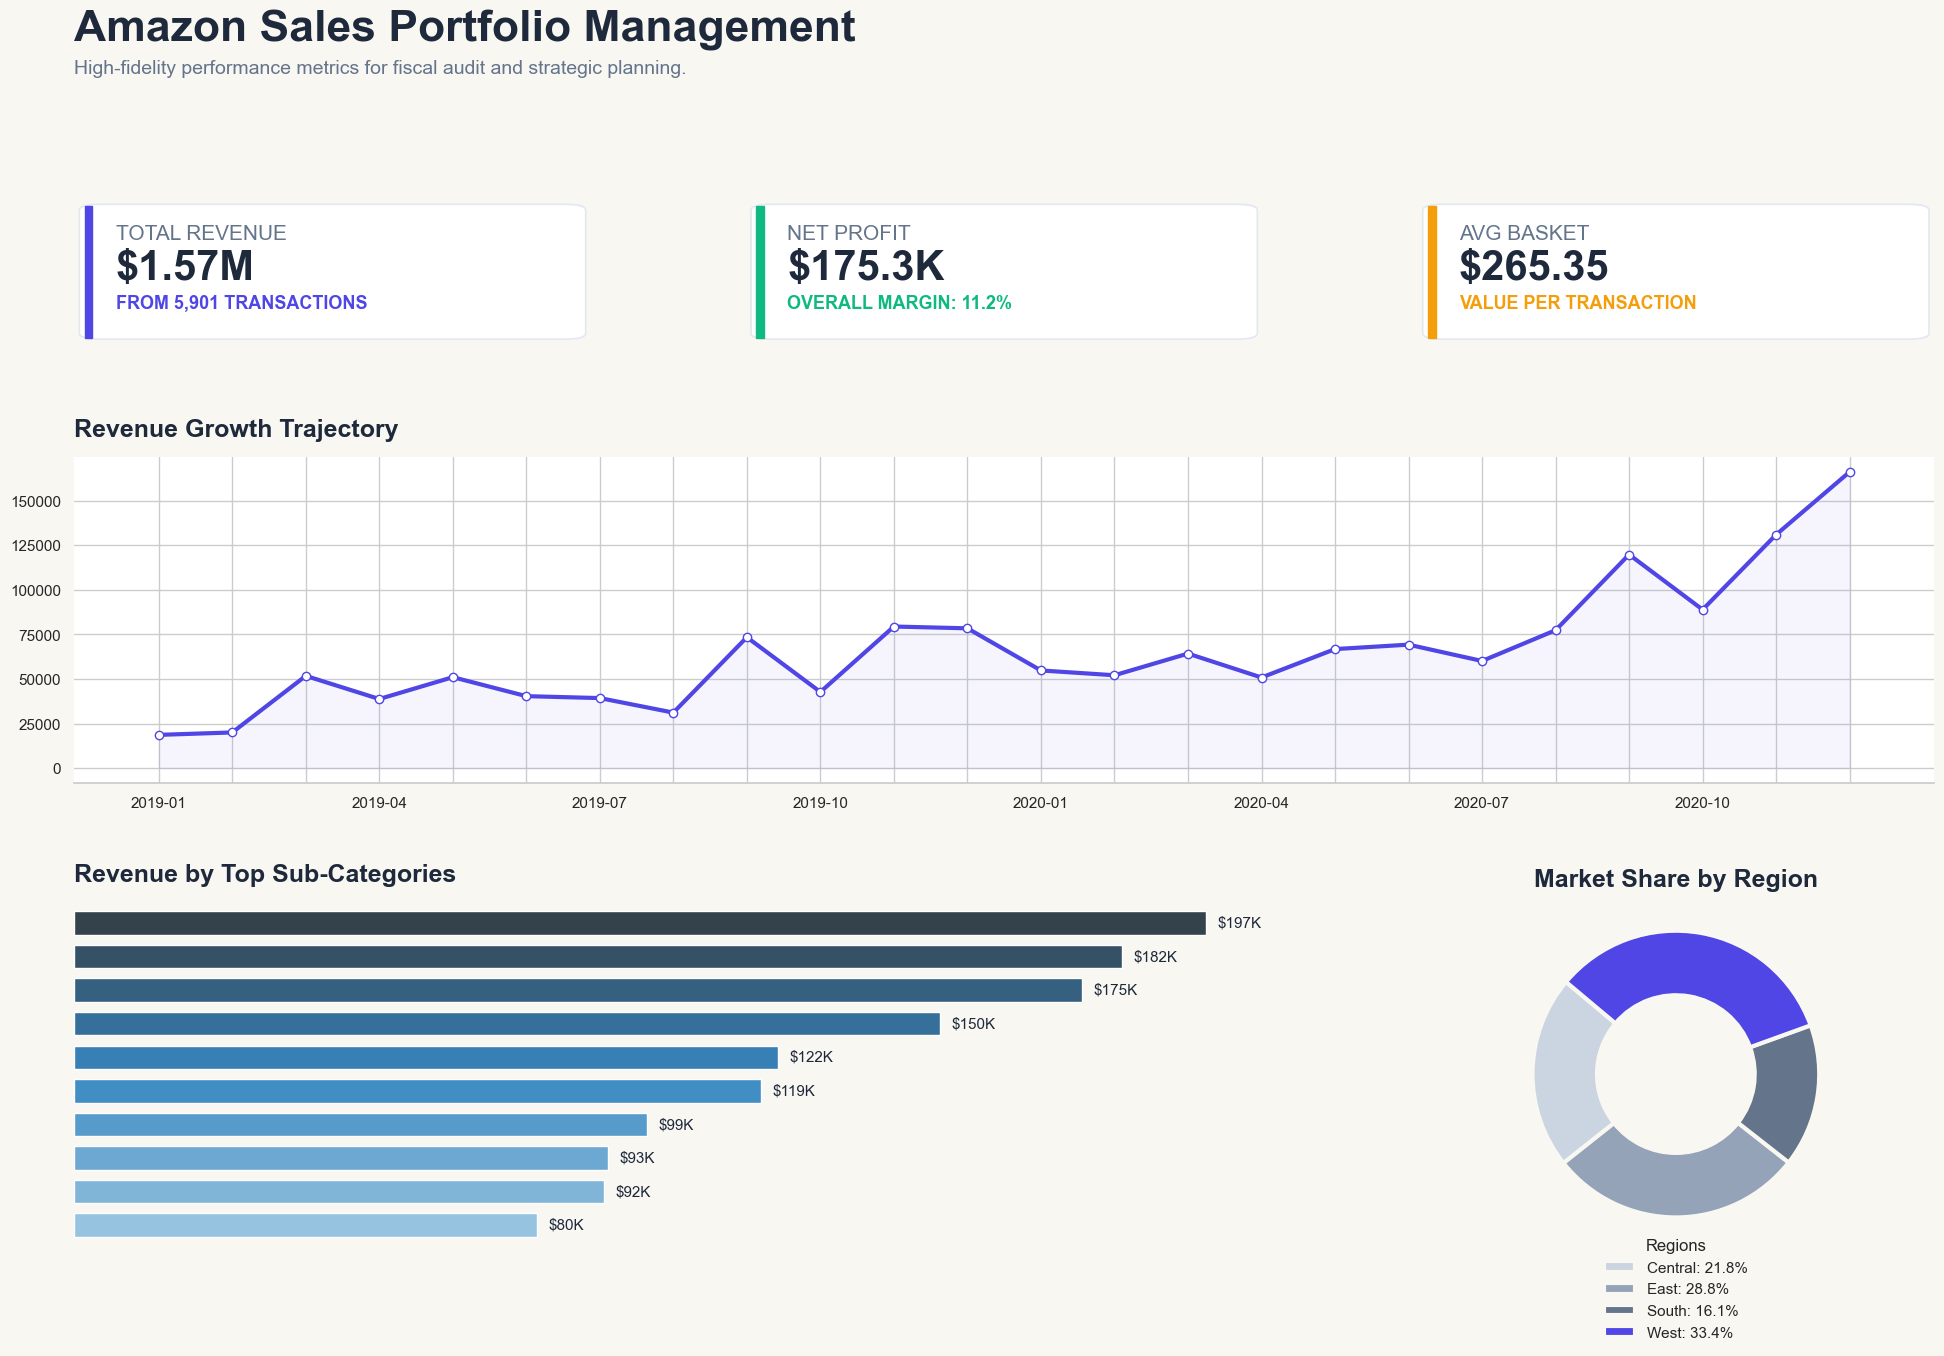

In [52]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Rectangle

# 1. Load & Process Data
df = pd.read_csv('Amazon Store Sales Data.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.sort_values('Order Date')
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# 2. Aggregations for KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df) # The transaction count
avg_order = df['Sales'].mean()
profit_margin = (total_profit / total_sales) * 100

# 3. Styling Variables
bg_color = '#F8F7F2'   
card_color = '#FFFFFF' 
text_main = '#1E293B'  
text_muted = '#64748B' 
accent_indigo = '#4F46E5'
accent_green = '#10B981'

plt.rcParams['font.family'] = 'sans-serif'
fig = plt.figure(figsize=(24, 16), facecolor=bg_color)
gs = gridspec.GridSpec(4, 3, height_ratios=[0.4, 0.9, 2, 2.2], hspace=0.5, wspace=0.3)

# Row 1: Dashboard Title
ax_title = fig.add_subplot(gs[0, :])
ax_title.text(0, 0.7, 'Amazon Sales Portfolio Management', fontsize=32, fontweight='bold', color=text_main)
ax_title.text(0, 0.2, 'High-fidelity performance metrics for fiscal audit and strategic planning.', fontsize=14, color=text_muted)
ax_title.axis('off')

def draw_kpi_fixed(ax, title, value, subtext, color):
    ax.set_facecolor(bg_color)
    # Background White Card
    rect = FancyBboxPatch((0.02, 0.05), 0.96, 0.9, boxstyle="round,pad=0.01,rounding_size=0.04",
                          fc=card_color, ec="#E2E8F0", lw=1.2, transform=ax.transAxes, zorder=1)
    ax.add_patch(rect)
    
    # Left vertical accent line to create visual separation
    accent_bar = Rectangle((0.02, 0.05), 0.015, 0.9, color=color, transform=ax.transAxes, zorder=2)
    ax.add_patch(accent_bar)

    # Text Placement - Ensures label is NOT mixed with value
    ax.text(0.08, 0.72, title, ha='left', fontsize=15, color=text_muted, fontweight='400', transform=ax.transAxes)
    ax.text(0.08, 0.45, value, ha='left', fontsize=30, color=text_main, fontweight='bold', transform=ax.transAxes)
    ax.text(0.08, 0.25, subtext, ha='left', fontsize=13, color=color, fontweight='bold', transform=ax.transAxes)
    ax.axis('off')

# KPI Display
draw_kpi_fixed(fig.add_subplot(gs[1, 0]), "TOTAL REVENUE", f"${total_sales/1e6:.2f}M", f"FROM {total_orders:,} TRANSACTIONS", accent_indigo)
draw_kpi_fixed(fig.add_subplot(gs[1, 1]), "NET PROFIT", f"${total_profit/1000:.1f}K", f"OVERALL MARGIN: {profit_margin:.1f}%", accent_green)
draw_kpi_fixed(fig.add_subplot(gs[1, 2]), "AVG BASKET", f"${avg_order:.2f}", "VALUE PER TRANSACTION", '#F59E0B')

# --- REVENUE TREND  ---
ax_trend = fig.add_subplot(gs[2, :])
trend_data = df.groupby('Month_Year')['Sales'].sum()
ax_trend.plot(trend_data.index, trend_data.values, color=accent_indigo, linewidth=3, marker='o', mfc='white')
ax_trend.fill_between(trend_data.index, trend_data.values, color=accent_indigo, alpha=0.05)
ax_trend.set_title('Revenue Growth Trajectory', fontsize=18, fontweight='bold', color=text_main, loc='left', pad=15)
for i, label in enumerate(ax_trend.xaxis.get_ticklabels()):
    if i % 3 != 0: label.set_visible(False)
plt.xticks(rotation=0)
sns.despine(left=True)

# --- PRODUCT BREAKDOWN ----
ax_cat = fig.add_subplot(gs[3, 0:2])
cat_perf = df.groupby('Sub-Category')['Sales'].sum().sort_values().tail(10)
bars = ax_cat.barh(cat_perf.index, cat_perf.values, color=sns.color_palette("Blues_d", 10), height=0.7)
ax_cat.set_title('Revenue by Top Sub-Categories', fontsize=18, fontweight='bold', color=text_main, loc='left', pad=10)
# Clean up bar labels
for bar in bars:
    ax_cat.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2, f'${bar.get_width()/1000:.0f}K', 
                va='center', fontsize=11, color=text_main)
ax_cat.axis('off')

# --- Row 3:---
ax_donut = fig.add_subplot(gs[3, 2])
region_dist = df.groupby('Region')['Sales'].sum()
# Using a Legend instead of labels on the slices to stop messiness
wedges, texts = ax_donut.pie(region_dist, startangle=140, 
                             colors=['#CBD5E1', '#94A3B8', '#64748B', accent_indigo], 
                             wedgeprops=dict(width=0.45, edgecolor=bg_color, linewidth=3))
ax_donut.legend(wedges, [f"{l}: {s/total_sales*100:.1f}%" for l, s in zip(region_dist.index, region_dist.values)],
                title="Regions", loc="center", bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=11)
ax_donut.set_title('Market Share by Region', fontsize=18, fontweight='bold', color=text_main)
plt.show()